# HH-PC vs LIF-PC on SHD: Timestep Sweep Evaluation

Same protocol as the MNIST/FMNIST/N-MNIST sweep, ported to **SHD** (Spiking
Heidelberg Digits, 20 classes, 700 cochlea channels).

- **2 neuron models**: Hodgkin-Huxley (`HHNeuron` from `hhpc_base.py`) and LIF
  (added here, ablation-only so not in the trimmed base), sharing identical
  PC inference / PC learning / metrics code.
- **Timestep sweep**: `steps_spk` from 10 to 70 (step 10).
- Reports test accuracy, macro-F1, spike rate, spikes/sample and PC energy at
  every `(neuron, steps_spk)` point, plus the HH-vs-LIF reduction summary.

SHD-specific settings carried over from the main SHD run (all held fixed
across the sweep so `steps_spk` is the only varying factor):

| setting | value | why |
|---|---|---|
| `TBINS x CH` | 50 x 140 | input binning, **independent** of `steps_spk` |
| `tau_ref` | 0.15 (5 steps) | default 2.0 = 67 steps > `steps_spk`, near-binary proxies |
| `I_bias` | `[1.5, 3.0]` | per-layer; output layer needs more drive at C=20 |
| PC targets | soft (0.9 / 0.005) | hard one-hot kills output classes at C=20 |
| split | speaker-level | file-level split leaks speakers into val |
| augmentation | time shift + channel dropout | train only |

`CALIBRATE_LIF = True` sweeps LIF's hidden `I_bias` at each timestep so its
hidden firing rate matches HH's before training. This is the protocol used in
the paired-seed HH/LIF study; set it to `False` to reproduce the uncalibrated
protocol of the MNIST notebook (both bias vectors identical).

**Compute:** 7 timesteps x 2 neuron types = **14 training runs**. The sweep
resumes from `RESULTS_CSV`, so an interrupted run picks back up. Set
`QUICK_TEST = True` for a smoke test first.


## 0. Setup

In [1]:
import os, sys, glob, gzip, shutil, time, json, math, types, urllib.request
from typing import List, Optional, Dict, Any, Tuple

import numpy as np
import pandas as pd
import torch, torch.nn as nn, torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

_hits = (glob.glob('/kaggle/input/**/hhpc_base.py', recursive=True) +
         glob.glob('/kaggle/working/**/hhpc_base.py', recursive=True) +
         glob.glob('./hhpc_base.py'))
assert _hits, 'hhpc_base.py not found — attach the dataset'
sys.path.insert(0, os.path.dirname(os.path.abspath(_hits[0])))
from hhpc_base import (PCSNNet, HHNeuron, MetricAccumulator, EarlyStopper,
                       one_hot, set_seed, default_device)

print('hhpc_base at:', _hits[0])
print('Torch:', torch.__version__, '| CUDA available:', torch.cuda.is_available())


hhpc_base at: /kaggle/input/datasets/ishraqkamaladib/hhpc-base/hhpc_base.py
Torch: 2.10.0+cu128 | CUDA available: True


In [2]:
# ── SHD constants (fixed across the whole sweep) ──────────────────────────
DATA_DIR    = '/kaggle/working/shd'
CKPT_DIR    = '/kaggle/working/ckpts_shd_sweep'
N_CH, POOL, TBINS, T_MAX = 700, 5, 50, 1.0
NUM_CLASSES = 20
CH   = N_CH // POOL          # 140 pooled channels
D_IN = TBINS * CH            # 7000

HIDDEN       = 400
DT           = 0.03
TAU_REF      = 0.15          # 5 refractory steps at dt=0.03
I_BIAS       = [1.5, 3.0]    # [hidden, output]
CURRENT_GAIN = 30.0
THR          = 0.8           # HH threshold (tanh-squashed membrane)
LIF_THR      = 1.0           # LIF threshold (raw Euler membrane)
LIF_TAU      = 0.3
T_TRAIN      = 100           # PC inference iters (unrelated to steps_spk)
T_EVAL       = 50
ETA_X        = 0.05
LR           = 2e-4
WD           = 2e-4
BATCH        = 128
N_VAL_SPK    = 2
SEED         = 123
TGT_HI, TGT_LO = 0.9, 0.1
TIME_SHIFT_MAX, CH_DROP_P = 4, 0.15

DEVICE = default_device()
set_seed(SEED)
os.makedirs(DATA_DIR, exist_ok=True); os.makedirs(CKPT_DIR, exist_ok=True)
print('device:', DEVICE, '| D_in:', D_IN, '| classes:', NUM_CLASSES)


device: cuda | D_in: 7000 | classes: 20


## 1. Data

SHD arrives as raw `(times, units)` event lists. They are binned once into a
fixed `TBINS x CH` frame, log-compressed and per-sample normalised — exactly
as in the main SHD run. The binned frame is flattened to a 7000-d vector and
the network Poisson-encodes it internally at whatever `steps_spk` the sweep is
using, so `TBINS` (input resolution) and `steps_spk` (simulation length) stay
independent.

In [3]:
# ── locate or download shd_train.h5 / shd_test.h5 ─────────────────────────
try:
    import h5py
except ImportError:
    os.system('pip install -q h5py'); import h5py

URLS = {'train': 'https://zenkelab.org/datasets/shd_train.h5.gz',
        'test':  'https://zenkelab.org/datasets/shd_test.h5.gz'}

def get_h5(split):
    for pat in (f'/kaggle/input/**/shd_{split}.h5', f'{DATA_DIR}/shd_{split}.h5',
                f'/kaggle/input/**/shd_{split}.h5.gz'):
        hits = glob.glob(pat, recursive=True)
        if hits:
            p = hits[0]
            if p.endswith('.gz'):
                out = f'{DATA_DIR}/shd_{split}.h5'
                if not os.path.exists(out):
                    with gzip.open(p, 'rb') as fi, open(out, 'wb') as fo:
                        shutil.copyfileobj(fi, fo)
                return out
            return p
    gz, out = f'{DATA_DIR}/shd_{split}.h5.gz', f'{DATA_DIR}/shd_{split}.h5'
    print(f'downloading {split} ...', flush=True)
    urllib.request.urlretrieve(URLS[split], gz)
    with gzip.open(gz, 'rb') as fi, open(out, 'wb') as fo:
        shutil.copyfileobj(fi, fo)
    return out

H5_TRAIN, H5_TEST = get_h5('train'), get_h5('test')
print('ok:', H5_TRAIN, H5_TEST)


downloading train ...
downloading test ...
ok: /kaggle/working/shd/shd_train.h5 /kaggle/working/shd/shd_test.h5


In [4]:
# ── bin (times, units) -> TBINS x CH frame ────────────────────────────────
def load_shd(path, tbins=TBINS, pool=POOL, n_ch=N_CH, t_max=T_MAX):
    ch = n_ch // pool
    with h5py.File(path, 'r') as f:
        times, units = f['spikes']['times'], f['spikes']['units']
        labels = np.asarray(f['labels'], np.int64)
        spk = (np.asarray(f['extra']['speaker'], np.int64)
               if 'extra' in f and 'speaker' in f['extra'] else np.zeros(len(labels), np.int64))
        X = np.zeros((len(labels), tbins * ch), np.float32)
        for i in range(len(labels)):
            t = np.asarray(times[i], np.float64); u = np.asarray(units[i], np.int64)
            if t.size == 0:
                continue
            ti = np.clip((t / t_max * tbins).astype(np.int64), 0, tbins - 1)
            ui = np.clip(u // pool, 0, ch - 1)
            cnt = np.log1p(np.bincount(ti * ch + ui, minlength=tbins * ch).astype(np.float32))
            m = cnt.max(); X[i] = cnt / m if m > 0 else cnt
    return X, labels, spk

t0 = time.time()
Xtr_all, ytr_all, spk_tr = load_shd(H5_TRAIN)
Xte,     yte,     spk_te = load_shd(H5_TEST)
print(f'loaded in {time.time()-t0:.1f}s | train {Xtr_all.shape} test {Xte.shape}')
print('train speakers:', np.unique(spk_tr), '| test speakers:', np.unique(spk_te))


loaded in 6.9s | train (8156, 7000) test (2264, 7000)
train speakers: [ 0  1  2  3  6  7  8  9 10 11] | test speakers: [ 0  1  2  3  4  5  6  7  8  9 10 11]


In [5]:
# ── speaker-level split + loaders (train-time augmentation) ───────────────
rng = np.random.RandomState(SEED)
spk_ids = np.unique(spk_tr)
val_spk = rng.choice(spk_ids, size=min(N_VAL_SPK, len(spk_ids)), replace=False)
val_mask = np.isin(spk_tr, val_spk)
tr_idx, val_idx = np.where(~val_mask)[0], np.where(val_mask)[0]
print('held-out val speakers:', val_spk, '| val n =', len(val_idx))

class AugmentedSHD(Dataset):
    """Random circular time shift + pooled-channel dropout, applied per __getitem__."""
    def __init__(self, X, y, tbins=TBINS, ch=CH, max_shift=TIME_SHIFT_MAX, drop_p=CH_DROP_P):
        self.X, self.y, self.tbins, self.ch = X, y, tbins, ch
        self.max_shift, self.drop_p = max_shift, drop_p
    def __len__(self):  return len(self.y)
    def __getitem__(self, i):
        x = self.X[i].reshape(self.tbins, self.ch)
        s = np.random.randint(-self.max_shift, self.max_shift + 1)
        if s: x = np.roll(x, s, axis=0)
        if self.drop_p > 0:
            x = x * (np.random.rand(self.ch) >= self.drop_p)[None, :]
        return torch.from_numpy(np.ascontiguousarray(x.reshape(-1))), int(self.y[i])

def to_ds(X, y, idx=None):
    if idx is not None: X, y = X[idx], y[idx]
    return TensorDataset(torch.from_numpy(X), torch.from_numpy(y))

_KW = dict(num_workers=0, pin_memory=DEVICE.startswith('cuda'))
TRAIN_LOADER = DataLoader(AugmentedSHD(Xtr_all[tr_idx], ytr_all[tr_idx]), BATCH,
                          shuffle=True, **_KW)
VAL_LOADER   = DataLoader(to_ds(Xtr_all, ytr_all, val_idx), BATCH, shuffle=False, **_KW)
TEST_LOADER  = DataLoader(to_ds(Xte, yte), BATCH, shuffle=False, **_KW)
print(len(TRAIN_LOADER.dataset), len(VAL_LOADER.dataset), len(TEST_LOADER.dataset))

def prepare_batch(x):
    """SHD samples are already flat 7000-d vectors; kept for interface parity."""
    return x.reshape(x.size(0), -1)


held-out val speakers: [6 0] | val n = 1360
6796 1360 2264


## 2. LIF neuron

Not in `hhpc_base.py` (trimmed as ablation-only). Matches `HHNeuron`'s
`forward(I) -> (spk, V)` / `reset_states(B)` interface exactly, so the model
builder can swap the two with one flag. `tau` is the membrane time constant
(`dV = (-V + I) * dt/tau`), LIF-specific with no HH equivalent. `tau_ref` is
shared, so both models sit out the same 5-step lockout.

In [6]:
class LIFNeuron(nn.Module):
    def __init__(self, N, dt=DT, device='cpu', thr=LIF_THR, reset=0.0,
                 tau=LIF_TAU, tau_ref=TAU_REF):
        super().__init__()
        self.N, self.dt, self.device = N, float(dt), device
        self.thr, self.reset, self.tau = float(thr), float(reset), float(tau)
        self.tau_ref = float(tau_ref)
        self.reset_states(1)

    def reset_states(self, B: int):
        self.B = B
        self.Vm   = torch.zeros(B, self.N, device=self.device)
        self.refr = torch.zeros(B, self.N, device=self.device)
        self.refr_steps = max(1, int(round(self.tau_ref / self.dt)))

    def forward(self, I: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        if I.shape[0] != getattr(self, 'B', None):
            self.reset_states(I.shape[0])
        can = (self.refr <= 0)
        Vn  = self.Vm + (-self.Vm + I) * (self.dt / max(self.tau, 1e-6))
        spk = ((Vn >= self.thr) & can).float()
        self.Vm = torch.where(spk.bool(), torch.full_like(Vn, self.reset), Vn)
        self.refr = torch.where(spk.bool(),
                                torch.full_like(self.refr, float(self.refr_steps)),
                                torch.clamp(self.refr - 1.0, min=0.0))
        return spk, self.Vm


## 3. Model builder

`PCSNNet` from the base file is reused unchanged for PC inference, PC learning
and the optimiser. Two things are patched on top:

1. **Cells** are swapped to `LIFNeuron` when `neuron_type='lif'`; for HH the
   refractory window is corrected to `tau_ref=0.15`.
2. **`forward_proxies`** is replaced with a version taking a *per-layer*
   `I_bias` list instead of one scalar — the output layer at `C=20` needs more
   standing drive than the hidden layer.

In [7]:
def _forward_proxies(self, x_in, steps_spk):
    """Poisson-encode the binned SHD frame, then simulate steps_spk steps
    with per-layer I_bias. Signature-compatible with PCSNNet.forward_proxies."""
    x0 = x_in.to(self.device).clamp(0, 1)
    B = x0.size(0)
    for cell in self.cells:
        cell.reset_states(B)

    p = (x0 * self.poisson_scale).clamp(0, 1)
    spk_train = (torch.rand(B, x0.size(1), steps_spk, device=self.device)
                 < p.unsqueeze(-1)).float()

    spike_sums = [torch.zeros(B, self.sizes[i+1], device=self.device) for i in range(self.S)]
    in_spk = 0.
    for t in range(steps_spk):
        r = spk_train[:, :, t]
        in_spk += float(r.sum())
        for i in range(self.S):
            I = F.linear(r, self.syn[i].weight, self.syn[i].bias) * self.current_gain \
                + self.I_bias_list[i]
            spk, _ = self.cells[i](I)
            spike_sums[i] += spk
            r = spk

    self._last_spike_sums = spike_sums
    self._input_spikes = in_spk
    return [x0] + [(ss / float(steps_spk)).clamp(0, 1) for ss in spike_sums]


def build_model(neuron_type='hh', i_bias=None, hidden=HIDDEN, seed=SEED):
    set_seed(seed)                      # identical init for HH and LIF at a given seed
    m = PCSNNet(layer_sizes=[D_IN, hidden, NUM_CLASSES], dt=DT, device=DEVICE,
                current_gain=CURRENT_GAIN, thr=THR, lr=LR, weight_decay=WD,
                pc_activation='relu', input_encoding='poisson').to(DEVICE)
    m.neuron_type   = neuron_type
    m.I_bias_list   = list(i_bias if i_bias is not None else I_BIAS)

    if neuron_type == 'lif':
        m.cells = nn.ModuleList([
            LIFNeuron(m.sizes[i+1], dt=DT, device=DEVICE, thr=LIF_THR,
                      tau=LIF_TAU, tau_ref=TAU_REF)
            for i in range(m.S)]).to(DEVICE)
    else:
        for c in m.cells:
            c.refr_steps = max(1, int(round(TAU_REF / DT)))

    m.forward_proxies = types.MethodType(_forward_proxies, m)
    m._input_spikes = 0.
    return m


# ── soft PC targets (hard one-hot freezes output rows at C=20) ────────────
def soft_one_hot(y, C, hi=TGT_HI, lo=TGT_LO):
    t = torch.full((y.size(0), C), lo / C, device=y.device)
    t.scatter_(1, y.view(-1, 1).long(), hi)
    return t

def make_target(y, C):
    return soft_one_hot(y, C)


## 4. Evaluation + spike accounting

In [8]:
@torch.no_grad()
def spike_rate_epoch(model, loader, device, steps_spk, eval_seed=1234):
    model.eval()
    S = model.S
    total_spk, total_den = [0.] * S, [0.] * S
    n_samples, in_spk = 0, 0.
    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, _ in loader:
            x = prepare_batch(x.to(device)); B = x.size(0)
            model.forward_proxies(x, steps_spk)
            ss = model.last_spike_sums()
            if ss is None:
                continue
            in_spk += model._input_spikes
            for li in range(S):
                total_spk[li] += float(ss[li].sum())
                total_den[li] += float(B * ss[li].shape[1] * steps_spk)
            n_samples += B
    return {'per_layer': [total_spk[i] / max(total_den[i], 1.) for i in range(S)],
            'total': sum(total_spk) / max(sum(total_den), 1.),
            'spikes_per_sample': sum(total_spk) / max(n_samples, 1),
            'input_per_sample': in_spk / max(n_samples, 1)}


@torch.no_grad()
def eval_epoch(model, loader, device, steps_spk, T_infer, eta_x,
               eval_mode='pc', eval_seed=1234):
    model.eval()
    C = model.sizes[-1]
    ff_acc, pc_acc = MetricAccumulator(C), MetricAccumulator(C)
    total_e, total = 0., 0
    with torch.random.fork_rng():
        torch.manual_seed(eval_seed)
        for x, y in loader:
            x = prepare_batch(x.to(device)); y = y.to(device); B = x.size(0)
            proxies = model.forward_proxies(x, steps_spk)

            ff_pred = proxies[-1].argmax(1)
            ff_acc.update(ff_pred.cpu(), y.cpu())

            if eval_mode == 'pc':
                xs, _, _, _ = model.pc_infer(proxies, None, T_infer, eta_x, False)
                pc_pred = xs[-1].argmax(1)
            else:
                pc_pred = ff_pred
            pc_acc.update(pc_pred.cpu(), y.cpu())

            _, _, _, e = model.pc_infer(proxies, one_hot(y, C), T_infer, eta_x, True)
            total_e += e * B; total += B

    ff_m, pc_m = ff_acc.compute(), pc_acc.compute()
    return {'ff_acc': ff_m['acc'], 'ff_f1': ff_m['f1'],
            'pc_acc': pc_m['acc'], 'pc_f1': pc_m['f1'],
            'pc_precision': pc_m['precision'], 'pc_recall': pc_m['recall'],
            'pc_energy': total_e / max(total, 1)}


## 5. Training loop

Same early-stopping loop as the base file. Two SHD changes: targets are soft
rather than hard one-hot, and early stopping monitors **macro-F1** rather than
accuracy (F1 is the metric that exposes dead output classes at `C=20`).

In [9]:
def train(model, train_loader, val_loader, device,
          steps_spk, T_infer_train, T_infer_eval,
          eta_x, epochs, eval_seed, patience, ckpt_path,
          verbose=False, show_rates=True):

    stopper = EarlyStopper(patience=patience)
    best_val_f1 = 0.
    history = []

    for epoch in range(1, epochs + 1):
        model.train()
        running_e, n_batches = 0.0, 0
        pbar = tqdm(train_loader, desc=f'Epoch {epoch}', disable=not verbose, leave=False)
        for x, y in pbar:
            x = prepare_batch(x.to(device)); y = y.to(device)
            energy, _ = model.train_step(x, make_target(y, model.sizes[-1]),
                                         steps_spk, T_infer_train, eta_x)
            running_e += energy; n_batches += 1
            if verbose:
                pbar.set_postfix(E=f'{running_e / max(n_batches,1):.4f}')

        va = eval_epoch(model, val_loader, device, steps_spk, T_infer_eval, eta_x,
                        'pc', eval_seed)
        monitor = va['pc_f1']
        stop, improved = stopper.step(monitor, epoch)
        if improved:
            torch.save(model.state_dict(), ckpt_path)
            best_val_f1 = monitor
        history.append({'epoch': epoch, 'train_energy': running_e / max(n_batches, 1),
                        'val_acc': va['pc_acc'], 'val_f1': va['pc_f1'],
                        'val_energy': va['pc_energy']})

        if verbose:
            if show_rates:
                rs = spike_rate_epoch(model, val_loader, device, steps_spk, eval_seed)
                print(f"Val Acc: {va['pc_acc']:.4f} | Val F1: {monitor:.4f} | "
                      f"Rates: {[round(r, 5) for r in rs['per_layer']]}"
                      f"{' *' if improved else ''}", flush=True)
            else:
                print(f"  Epoch {epoch:02d} | val_f1={monitor:.4f}"
                      f"{' *' if improved else ''}", flush=True)
        if stop:
            if verbose:
                print(f'  Early stop at epoch {epoch} (best {stopper.best_epoch})')
            break

    if os.path.exists(ckpt_path):
        model.load_state_dict(torch.load(ckpt_path, map_location=device))
    return best_val_f1, history


## 6. LIF bias calibration

HH and LIF integrate on different voltage scales, so the same `I_bias` gives
them different standing firing rates — and spike counts are the thing being
compared. This grid-searches LIF's hidden `I_bias` at each `steps_spk` so its
untrained hidden rate matches HH's, then scales the output bias by the same
factor. Applied before training, on a single probe batch, so it costs almost
nothing. Set `CALIBRATE_LIF = False` to skip it and give both models the
identical bias vector instead.

In [10]:
@torch.no_grad()
def _hidden_rate(model, xb, steps_spk, seed=999):
    with torch.random.fork_rng():
        torch.manual_seed(seed)
        model.forward_proxies(xb, steps_spk)
    ss = model.last_spike_sums()[0]
    return float(ss.sum()) / (ss.shape[0] * ss.shape[1] * steps_spk)


def calibrate_lif_bias(steps_spk, probe_loader, grid=None, seed=SEED, verbose=True):
    """Return an I_bias list for LIF whose init hidden rate matches HH's."""
    grid = grid if grid is not None else np.concatenate([np.arange(0.1, 3.01, 0.1),
                                                         np.arange(3.5, 10.01, 0.5)])
    xb, _ = next(iter(probe_loader))
    xb = prepare_batch(xb.to(DEVICE))

    hh = build_model('hh', I_BIAS, seed=seed)
    target = _hidden_rate(hh, xb, steps_spk)
    del hh

    best, best_gap = I_BIAS[0], float('inf')
    lif = build_model('lif', I_BIAS, seed=seed)
    for b in grid:
        lif.I_bias_list = [float(b), I_BIAS[1]]
        gap = abs(_hidden_rate(lif, xb, steps_spk) - target)
        if gap < best_gap:
            best, best_gap = float(b), gap
    lif.I_bias_list = [best, I_BIAS[1]]
    got = _hidden_rate(lif, xb, steps_spk)
    del lif

    scale = best / max(I_BIAS[0], 1e-8)
    out = [best, I_BIAS[1] * scale]
    if verbose:
        print(f'  [calib T={steps_spk}] HH hidden rate {target:.5f} -> '
              f'LIF I_bias {out[0]:.2f}/{out[1]:.2f} (rate {got:.5f})', flush=True)
    return out


## 7. Single-run entry point

In [11]:
def run_experiment(neuron_type, steps_spk, hidden=HIDDEN, epochs=25,
                   T_infer_train=T_TRAIN, T_infer_eval=T_EVAL, eta_x=ETA_X,
                   device=None, ckpt_dir=CKPT_DIR, patience=5,
                   calibrate_lif=True, verbose=True, seed=SEED):
    device = device or DEVICE
    set_seed(seed)

    i_bias = I_BIAS
    if neuron_type == 'lif' and calibrate_lif:
        i_bias = calibrate_lif_bias(steps_spk, VAL_LOADER, seed=seed, verbose=verbose)

    model = build_model(neuron_type, i_bias, hidden=hidden, seed=seed)
    os.makedirs(ckpt_dir, exist_ok=True)
    ckpt_path = os.path.join(ckpt_dir, f'SHD_{neuron_type}_T{steps_spk}.pt')

    if verbose:
        print(f'\n--- Training {neuron_type.upper()}-PC (SHD, T={steps_spk}, '
              f'I_bias={[round(b,2) for b in i_bias]}) ---', flush=True)

    t0 = time.time()
    best_val_f1, history = train(model, TRAIN_LOADER, VAL_LOADER, device,
                                 steps_spk, T_infer_train, T_infer_eval, eta_x,
                                 epochs, 1234, patience, ckpt_path, verbose)
    elapsed = time.time() - t0

    test_stats = eval_epoch(model, TEST_LOADER, device, steps_spk,
                            T_infer_eval, eta_x, 'pc', 1234)
    spk = spike_rate_epoch(model, TEST_LOADER, device, steps_spk, 1234)

    return {'dataset': 'SHD', 'neuron_type': neuron_type, 'steps_spk': steps_spk,
            'i_bias_hidden': round(i_bias[0], 3), 'i_bias_out': round(i_bias[1], 3),
            'best_val_f1': best_val_f1,
            'test_pc_acc': test_stats['pc_acc'], 'test_pc_f1': test_stats['pc_f1'],
            'test_ff_acc': test_stats['ff_acc'], 'test_ff_f1': test_stats['ff_f1'],
            'pc_precision': test_stats['pc_precision'],
            'pc_recall': test_stats['pc_recall'],
            'pc_energy': test_stats['pc_energy'],
            'spike_rate_total': spk['total'],
            'spike_rate_per_layer': spk['per_layer'],
            'spikes_per_sample': spk['spikes_per_sample'],
            'input_spikes_per_sample': spk['input_per_sample'],
            'epochs_run': len(history), 'train_time_s': elapsed,
            'history': history}


## 8. Sweep configuration

Set `QUICK_TEST = True` to sanity-check the pipeline (2 timestep values,
2 epochs) before committing to the full sweep.

In [12]:
QUICK_TEST = False    # set True for a fast smoke test

TIMESTEPS      = list(range(10, 71, 10))   # 10, 20, 30, 40, 50, 60, 70
NEURON_TYPES   = ['hh', 'lif']
EPOCHS         = 25
PATIENCE       = 5
CALIBRATE_LIF  = True     # False -> both models get the identical I_BIAS vector
RESULTS_CSV    = '/kaggle/working/shd_sweep_results.csv'

if QUICK_TEST:
    TIMESTEPS = [10, 30]
    EPOCHS = 2
    RESULTS_CSV = '/kaggle/working/shd_sweep_results_quick.csv'

n_runs = len(TIMESTEPS) * len(NEURON_TYPES)
print(f'Device: {DEVICE}')
print(f'Sweep: SHD x {len(TIMESTEPS)} timesteps x {len(NEURON_TYPES)} neuron types '
      f'= {n_runs} runs | epochs<={EPOCHS} | calibrate_lif={CALIBRATE_LIF}')


Device: cuda
Sweep: SHD x 7 timesteps x 2 neuron types = 14 runs | epochs<=25 | calibrate_lif=True


## 9. Sweep driver

Trains HH-PC then LIF-PC at every `steps_spk`, printing the spike-rate and
energy comparison after each pair, and appending every finished run to
`RESULTS_CSV`. Re-running this cell **resumes** — any
`(neuron_type, steps_spk)` already in the CSV is skipped.

In [13]:
def _load_existing_results(csv_path):
    if os.path.exists(csv_path):
        df = pd.read_csv(csv_path)
        return df, set(zip(df['neuron_type'], df['steps_spk']))
    return pd.DataFrame(), set()


def _append_result(csv_path, result):
    row = {k: (json.dumps(v) if isinstance(v, (list, dict)) else v)
           for k, v in result.items()}
    pd.DataFrame([row]).to_csv(csv_path, mode='a',
                               header=not os.path.exists(csv_path), index=False)


results_df, done_keys = _load_existing_results(RESULTS_CSV)
if len(done_keys):
    print(f'Resuming: {len(done_keys)} runs already completed in {RESULTS_CSV}')

for T in TIMESTEPS:
    run_results = {}
    for neuron_type in NEURON_TYPES:
        key = (neuron_type, T)
        if key in done_keys:
            print(f'Skipping SHD | {neuron_type.upper()}-PC | T={T} (already done)')
            continue
        res = run_experiment(neuron_type=neuron_type, steps_spk=T,
                             hidden=HIDDEN, epochs=EPOCHS, patience=PATIENCE,
                             calibrate_lif=CALIBRATE_LIF, verbose=True)
        _append_result(RESULTS_CSV, res)
        done_keys.add(key)
        run_results[neuron_type] = res
        print(f"  -> acc {res['test_pc_acc']*100:.2f}%  F1 {res['test_pc_f1']*100:.2f}%  "
              f"SR {res['spike_rate_total']:.5f}  SPS {res['spikes_per_sample']:.1f}  "
              f"({res['train_time_s']:.0f}s)", flush=True)

    if 'hh' in run_results and 'lif' in run_results:
        hh, lif = run_results['hh'], run_results['lif']
        print(f'\n--- Spike Rate Analysis (SHD, T={T}) ---')
        print(f"HH Average Spike Rate:  {hh['spike_rate_total']*100:.4f}%")
        print(f"LIF Average Spike Rate: {lif['spike_rate_total']*100:.4f}%")
        if lif['spike_rate_total'] > 0:
            print(f"Spike Rate Reduction (HH vs LIF): "
                  f"{(1 - hh['spike_rate_total']/lif['spike_rate_total'])*100:.2f}%")
        print(f"Spikes/sample — HH {hh['spikes_per_sample']:.1f} vs "
              f"LIF {lif['spikes_per_sample']:.1f}")

        print(f'\n--- Energy / Accuracy Analysis (SHD, T={T}) ---')
        print(f"HH  PC energy {hh['pc_energy']:.6f} | acc {hh['test_pc_acc']*100:.2f}% "
              f"| F1 {hh['test_pc_f1']*100:.2f}%")
        print(f"LIF PC energy {lif['pc_energy']:.6f} | acc {lif['test_pc_acc']*100:.2f}% "
              f"| F1 {lif['test_pc_f1']*100:.2f}%")
        if lif['pc_energy'] > 0:
            print(f"Energy Reduction (HH vs LIF): "
                  f"{(1 - hh['pc_energy']/lif['pc_energy'])*100:.2f}%")
        print()

results_df, _ = _load_existing_results(RESULTS_CSV)
results_df



--- Training HH-PC (SHD, T=10, I_bias=[1.5, 3.0]) ---


Epoch 1:   0%|          | 0/54 [00:00<?, ?it/s]

/usr/lib/python3.12/contextlib.py:137: UserWarning: CUDA reports that you have 2 available devices, and you have used fork_rng without explicitly specifying which devices are being used. For safety, we initialize *every* CUDA device by default, which can be quite slow if you have a lot of CUDAs. If you know that you are only making use of a few CUDA devices, set the environment variable CUDA_VISIBLE_DEVICES or the 'devices' keyword argument of fork_rng with the set of devices you are actually using. For example, if you are using CPU only, set device.upper()_VISIBLE_DEVICES= or devices=[]; if you are using device 0 only, set CUDA_VISIBLE_DEVICES=0 or devices=[0].  To initialize all devices and suppress this warning, set the 'devices' keyword argument to `range(torch.cuda.device_count())`.
  return next(self.gen)


Val Acc: 0.4794 | Val F1: 0.4274 | Rates: [0.06447, 0.04334] *


Epoch 2:   0%|          | 0/54 [00:00<?, ?it/s]

...

Epoch 17:   0%|          | 0/54 [00:00<?, ?it/s]

Val Acc: 0.7699 | Val F1: 0.7665 | Rates: [0.06665, 0.01727]


Epoch 18:   0%|          | 0/54 [00:00<?, ?it/s]

Val Acc: 0.7309 | Val F1: 0.7352 | Rates: [0.06489, 0.01976]
  Early stop at epoch 18 (best 13)
  -> acc 82.16%  F1 81.28%  SR 0.06388  SPS 1878.1  (190s)

--- Spike Rate Analysis (SHD, T=70) ---
HH Average Spike Rate:  6.7046%
LIF Average Spike Rate: 6.3880%
Spike Rate Reduction (HH vs LIF): -4.96%
Spikes/sample — HH 1971.2 vs LIF 1878.1

--- Energy / Accuracy Analysis (SHD, T=70) ---
HH  PC energy 0.002639 | acc 84.10% | F1 83.44%
LIF PC energy 0.001814 | acc 82.16% | F1 81.28%
Energy Reduction (HH vs LIF): -45.45%



,dataset,neuron_type,steps_spk,i_bias_hidden,i_bias_out,best_val_f1,test_pc_acc,test_pc_f1,test_ff_acc,test_ff_f1,pc_precision,pc_recall,pc_energy,spike_rate_total,spike_rate_per_layer,spikes_per_sample,input_spikes_per_sample,epochs_run,train_time_s,history
0,SHD,hh,10,1.5,3.0,0.766967,0.817580,0.809417,0.636926,0.609230,0.855531,0.814548,0.001738,0.052847,"[0.05415878975265018, 0.026607773851590105]",221.956714,7820.478799,18,126.532277,"[{""epoch"": 1, ""train_energy"": 0.01133088513489..."
1,SHD,lif,10,0.1,0.2,0.782858,0.858657,0.855350,0.606890,0.594915,0.863247,0.856361,0.002037,0.081556,"[0.0843791961130742, 0.0250839222614841]",342.533569,7820.478799,16,78.098481,"[{""epoch"": 1, ""train_energy"": 0.01202729577481..."
2,SHD,hh,20,1.5,3.0,0.768403,0.868375,0.864328,0.774293,0.766788,0.871092,0.864153,0.002056,0.057633,"[0.05913504858657244, 0.027599381625441698]",484.120141,15638.837898,14,135.078584,"[{""epoch"": 1, ""train_energy"": 0.01116916511118..."
3,SHD,lif,20,0.1,0.2,0.771710,0.868816,0.858683,0.694788,0.683025,0.871126,0.866849,0.001936,0.071209,"[0.07368164752650176, 0.021745803886925794]",598.151502,15638.837898,16,86.582798,"[{""epoch"": 1, ""train_energy"": 0.01179570410803..."
4,SHD,hh,30,1.5,3.0,0.762867,0.813604,0.807254,0.564929,0.567807,0.844289,0.812626,0.003046,0.063644,"[0.06540812720848056, 0.028362043580683158]",801.914753,23458.007509,12,148.395934,"[{""epoch"": 1, ""train_energy"": 0.01129918453174..."
5,SHD,lif,30,0.1,0.2,0.762521,0.827739,0.811138,0.624558,0.609601,0.853528,0.826874,0.002081,0.061958,"[0.06406824204946997, 0.01974676089517079]",780.666961,23458.007509,22,145.572678,"[{""epoch"": 1, ""train_energy"": 0.01169282428680..."
6,SHD,hh,40,1.5,3.0,0.747256,0.851590,0.851088,0.732332,0.730871,0.872237,0.848662,0.002265,0.064632,"[0.06654414200530036, 0.02639796819787986]",1085.824647,31282.462456,14,208.273292,"[{""epoch"": 1, ""train_energy"": 0.01226172446641..."
7,SHD,lif,40,0.1,0.2,0.727078,0.817580,0.791138,0.664753,0.641086,0.787703,0.814082,0.003342,0.068411,"[0.0708377871024735, 0.019878533568904594]",1149.307420,31282.462456,16,121.322108,"[{""epoch"": 1, ""train_energy"": 0.01189444379525..."
8,SHD,hh,50,1.5,3.0,0.769955,0.813604,0.806203,0.716431,0.701078,0.846104,0.812173,0.002545,0.064268,"[0.06619763692579506, 0.025682420494699647]",1349.635159,39098.969965,13,230.043392,"[{""epoch"": 1, ""train_energy"": 0.01169057408750..."
9,SHD,lif,50,0.1,0.2,0.761827,0.841873,0.830545,0.649293,0.648521,0.858957,0.840182,0.002471,0.073781,"[0.07650446113074205, 0.019306537102473497]",1549.395760,39098.969965,13,108.724112,"[{""epoch"": 1, ""train_energy"": 0.01094739986028..."


## 10. Results table

In [14]:
results_df = pd.read_csv(RESULTS_CSV)
results_df['spike_rate_per_layer'] = results_df['spike_rate_per_layer'].apply(json.loads)
results_df = results_df.sort_values(['steps_spk', 'neuron_type']).reset_index(drop=True)

show = ['steps_spk', 'neuron_type', 'test_pc_acc', 'test_pc_f1',
        'spike_rate_total', 'spikes_per_sample', 'pc_energy',
        'i_bias_hidden', 'epochs_run', 'train_time_s']
display(results_df[show].round(5))


,steps_spk,neuron_type,test_pc_acc,test_pc_f1,spike_rate_total,spikes_per_sample,pc_energy,i_bias_hidden,epochs_run,train_time_s
0,10,hh,0.81758,0.80942,0.05285,221.95671,0.00174,1.5,18,126.53228
1,10,lif,0.85866,0.85535,0.08156,342.53357,0.00204,0.1,16,78.09848
2,20,hh,0.86837,0.86433,0.05763,484.12014,0.00206,1.5,14,135.07858
3,20,lif,0.86882,0.85868,0.07121,598.15150,0.00194,0.1,16,86.58280
4,30,hh,0.81360,0.80725,0.06364,801.91475,0.00305,1.5,12,148.39593
5,30,lif,0.82774,0.81114,0.06196,780.66696,0.00208,0.1,22,145.57268
6,40,hh,0.85159,0.85109,0.06463,1085.82465,0.00227,1.5,14,208.27329
7,40,lif,0.81758,0.79114,0.06841,1149.30742,0.00334,0.1,16,121.32211
8,50,hh,0.81360,0.80620,0.06427,1349.63516,0.00254,1.5,13,230.04339
9,50,lif,0.84187,0.83054,0.07378,1549.39576,0.00247,0.1,13,108.72411


In [15]:
# ── paired HH-vs-LIF summary across the sweep ─────────────────────────────
piv = results_df.pivot(index='steps_spk', columns='neuron_type',
                       values=['test_pc_acc', 'test_pc_f1',
                               'spike_rate_total', 'spikes_per_sample', 'pc_energy'])

summary = pd.DataFrame({
    'acc_hh':      piv[('test_pc_acc', 'hh')] * 100,
    'acc_lif':     piv[('test_pc_acc', 'lif')] * 100,
    'f1_hh':       piv[('test_pc_f1', 'hh')] * 100,
    'f1_lif':      piv[('test_pc_f1', 'lif')] * 100,
    'rate_hh':     piv[('spike_rate_total', 'hh')],
    'rate_lif':    piv[('spike_rate_total', 'lif')],
    'sps_hh':      piv[('spikes_per_sample', 'hh')],
    'sps_lif':     piv[('spikes_per_sample', 'lif')],
})
summary['acc_delta_pts']  = summary['acc_hh'] - summary['acc_lif']
summary['f1_delta_pts']   = summary['f1_hh'] - summary['f1_lif']
summary['rate_reduc_pct'] = (1 - summary['rate_hh'] / summary['rate_lif']) * 100
summary['sps_reduc_pct']  = (1 - summary['sps_hh'] / summary['sps_lif']) * 100
display(summary.round(3))

wins = int((summary['rate_reduc_pct'] > 0).sum()); n = len(summary)
print(f"\nHH fires fewer spikes at {wins}/{n} timestep points "
      f"(reduction range {summary['rate_reduc_pct'].min():.1f}% to "
      f"{summary['rate_reduc_pct'].max():.1f}%)")
print(f"Mean accuracy delta (HH - LIF): {summary['acc_delta_pts'].mean():+.2f} pts | "
      f"mean macro-F1 delta: {summary['f1_delta_pts'].mean():+.2f} pts")

summary.to_csv('/kaggle/working/shd_sweep_summary.csv')
print('saved -> /kaggle/working/shd_sweep_summary.csv')


,acc_hh,acc_lif,f1_hh,f1_lif,rate_hh,rate_lif,sps_hh,sps_lif,acc_delta_pts,f1_delta_pts,rate_reduc_pct,sps_reduc_pct
steps_spk,,,,,,,,,,,,
10,81.758,85.866,80.942,85.535,0.053,0.082,221.957,342.534,-4.108,-4.593,35.201,35.201
20,86.837,86.882,86.433,85.868,0.058,0.071,484.120,598.152,-0.044,0.564,19.064,19.064
30,81.360,82.774,80.725,81.114,0.064,0.062,801.915,780.667,-1.413,-0.388,-2.722,-2.722
40,85.159,81.758,85.109,79.114,0.065,0.068,1085.825,1149.307,3.401,5.995,5.524,5.524
50,81.360,84.187,80.620,83.054,0.064,0.074,1349.635,1549.396,-2.827,-2.434,12.893,12.893
60,82.332,85.380,80.787,85.270,0.066,0.068,1673.482,1705.933,-3.048,-4.482,1.902,1.902
70,84.099,82.155,83.435,81.281,0.067,0.064,1971.164,1878.069,1.943,2.155,-4.957,-4.957



HH fires fewer spikes at 5/7 timestep points (reduction range -5.0% to 35.2%)
Mean accuracy delta (HH - LIF): -0.87 pts | mean macro-F1 delta: -0.45 pts
saved -> /kaggle/working/shd_sweep_summary.csv


## 11. Plots — accuracy, macro-F1, spike rate, energy vs. timesteps

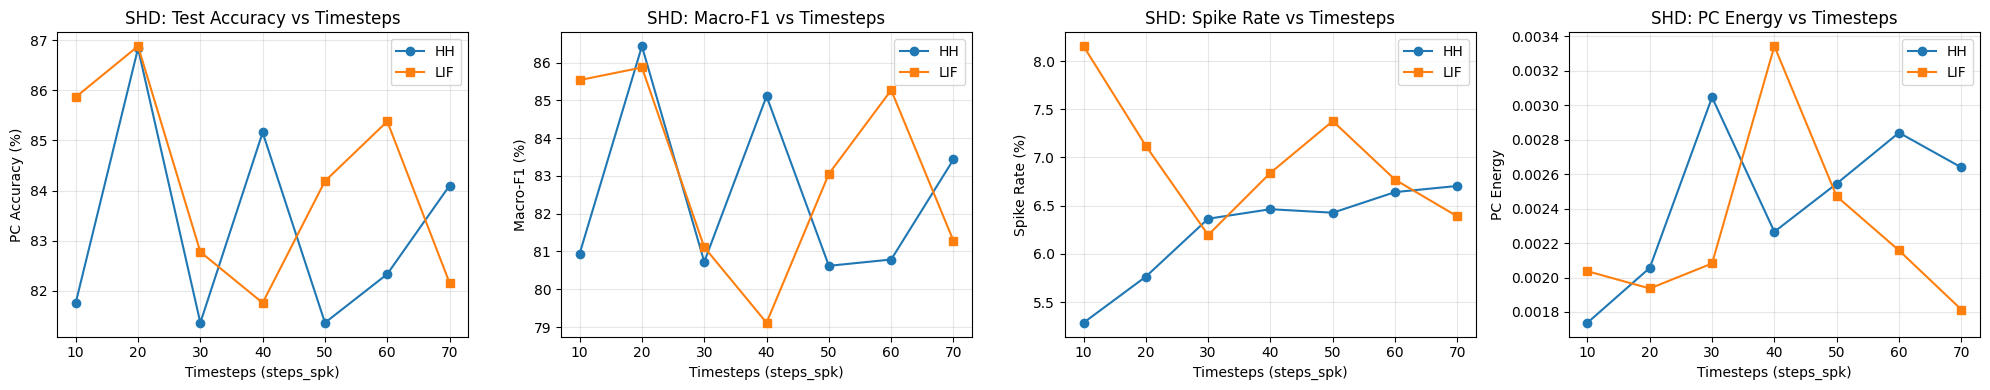

In [16]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4))

for neuron_type, marker in [('hh', 'o'), ('lif', 's')]:
    s = results_df[results_df['neuron_type'] == neuron_type].sort_values('steps_spk')
    if s.empty:
        continue
    lbl = neuron_type.upper()
    axes[0].plot(s['steps_spk'], s['test_pc_acc'] * 100, marker=marker, label=lbl)
    axes[1].plot(s['steps_spk'], s['test_pc_f1'] * 100, marker=marker, label=lbl)
    axes[2].plot(s['steps_spk'], s['spike_rate_total'] * 100, marker=marker, label=lbl)
    axes[3].plot(s['steps_spk'], s['pc_energy'], marker=marker, label=lbl)

for ax, title, ylab in zip(
        axes,
        ['SHD: Test Accuracy vs Timesteps', 'SHD: Macro-F1 vs Timesteps',
         'SHD: Spike Rate vs Timesteps', 'SHD: PC Energy vs Timesteps'],
        ['PC Accuracy (%)', 'Macro-F1 (%)', 'Spike Rate (%)', 'PC Energy']):
    ax.set_title(title); ax.set_xlabel('Timesteps (steps_spk)'); ax.set_ylabel(ylab)
    ax.legend(); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('/kaggle/working/shd_sweep_plots.png', dpi=150, bbox_inches='tight')
plt.show()
